In [2]:
import pandas as pd
import numpy as np
import datetime
import os
import pickle
import duckdb
from scipy import stats
import optuna
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from pathlib import Path

os.chdir(Path().resolve().parent)

In [3]:
con = duckdb.connect('notebooks/credit_risk.db')

# читаем предикторы из mart
df = con.execute("SELECT * FROM mart.features").df()
print(df.shape)
print(df['is_default'].value_counts())

(1341110, 18)
is_default
0    1073336
1     267774
Name: count, dtype: int64


In [9]:
FEATURES = [
    'dti', 'fico_avg', 'annual_inc', 'loan_amnt',
    'installment', 'open_acc', 'revol_util', 'total_acc',
    'loan_to_income', 'payment_to_income',
    'term_months', 'home_ownership', 'purpose'
]

df_model = df[FEATURES + ['is_default']].dropna()
df_model = pd.get_dummies(df_model,
                            columns=['home_ownership', 'purpose'],
                            drop_first=True)

FEATURES_ENC = [c for c in df_model.columns if c != 'is_default']

X = df_model[FEATURES_ENC]
y = df_model['is_default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Предикторов после кодирования: {len(FEATURES_ENC)}")
print(f"Строк: {X_train.shape[0]}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Предикторов после кодирования: 29
Строк: 1072209


In [11]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 600),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'scale_pos_weight': 4,
        'random_state': 42,
        'verbosity': 0,
        'eval_metric': 'auc'
    }
    
    model = xgb.XGBClassifier(**params)
    
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring='roc_auc')
    
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30) 

print(f"Лучший AUC на кросс-валидации: {study.best_value:.4f}")
print(f"Лучшие параметры: {study.best_params}")

Лучший AUC на кросс-валидации: 0.7102
Лучшие параметры: {'n_estimators': 485, 'max_depth': 4, 'learning_rate': 0.1375549686786709, 'subsample': 0.7196688425816651, 'colsample_bytree': 0.9391065793510344, 'min_child_weight': 9}


In [5]:
def compute_metrics(y_true, y_pred_proba):
    auc  = roc_auc_score(y_true, y_pred_proba)
    gini = 2 * auc - 1
    
    # KS статистика
    defaults     = y_pred_proba[y_true == 1]
    non_defaults = y_pred_proba[y_true == 0]
    ks = stats.ks_2samp(defaults, non_defaults).statistic
    
    return {"AUC": round(auc, 4), "Gini": round(gini, 4), "KS": round(ks, 4)}

In [6]:
# Логистическая регрессия
model_lr = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
model_lr.fit(X_train_scaled, y_train)    
y_pred = model_lr.predict_proba(X_test_scaled)[:, 1]
metrics = compute_metrics(y_test.values, y_pred)
    
print("Логистическая регрессия:")
for k, v in metrics.items():
    print(f"  {k}: {v}")

Логистическая регрессия:
  AUC: 0.6961
  Gini: 0.3921
  KS: 0.2818


In [7]:
model_xgb = xgb.XGBClassifier(
    n_estimators=514,
    max_depth=4,
    learning_rate=0.1363,
    subsample=0.9514,
    colsample_bytree=0.72,
    scale_pos_weight=4,
    random_state=42,
    min_child_weight = 8,
    eval_metric='auc',
    verbosity=0
    )
    
model_xgb.fit(X_train, y_train)
    
y_pred_xgb = model_xgb.predict_proba(X_test)[:, 1]
metrics_xgb = compute_metrics(y_test.values, y_pred_xgb)
    
print("XGBoost:")
for k, v in metrics_xgb.items():
    print(f"  {k}: {v}")

XGBoost:
  AUC: 0.7109
  Gini: 0.4219
  KS: 0.3064


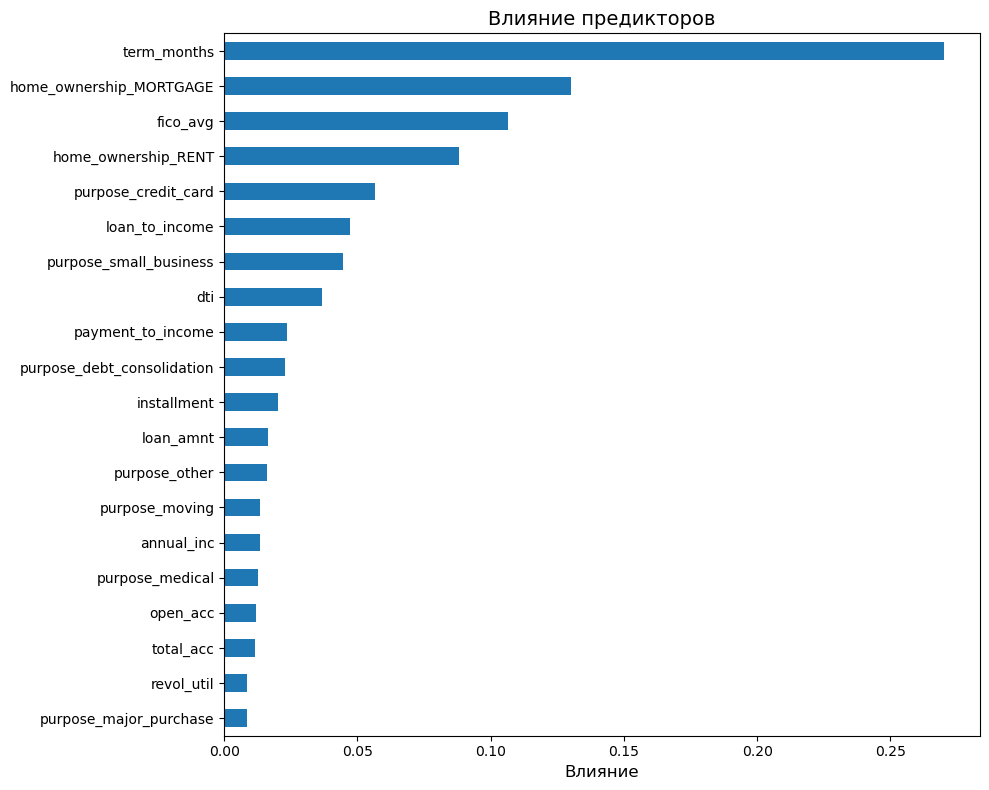

In [8]:
feat_imp = pd.Series(
    model_xgb.feature_importances_,
    index=FEATURES_ENC 
).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
feat_imp.tail(20).plot(kind='barh')
plt.title('Влияние предикторов', fontsize=14)
plt.xlabel('Влияние', fontsize=12)
plt.tight_layout()
plt.show()

In [10]:
con.close()

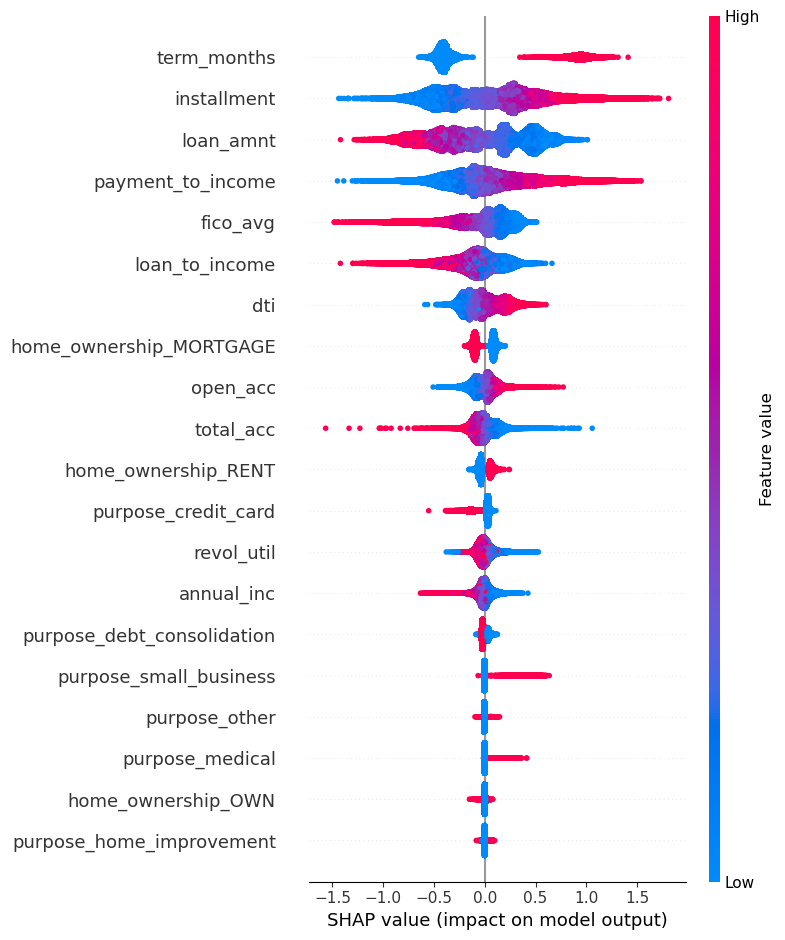

In [12]:
import shap

explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [8]:
# Logit
os.makedirs('models', exist_ok=True)
with open('models/model_lr_v2.pkl', 'wb') as f:
    pickle.dump(model_lr, f)

# XGBoost
model_xgb.save_model('models/model_xgb_v2.ubj')

# скейлер
with open('models/scaler_v2.pkl', 'wb') as f:
    pickle.dump(scaler, f)

Модели сохранены в models/


In [13]:
con.close()